<a href="https://colab.research.google.com/github/Achyuth060/ML-24148/blob/main/KNN/CH_SC_U4CSE24148(KNN1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import os
import zipfile
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import classification_report
import seaborn as sns
import zipfile

zip_path = "CH.SC.U4CSE24148_EX-9.6_1(KNN).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("ZIP file extracted successfully")

ZIP file extracted successfully


In [2]:
print(os.listdir("/content"))

['.config', 'trainingDigits', 'CH.SC.U4CSE24148_EX-9.6_1(KNN).zip', 'testDigits', 'sample_data']


In [3]:
def img2vector(filename):
    returnVect = np.zeros((1, 1024))

    fr = open(filename)

    for i in range(32):
        lineStr = fr.readline()

        for j in range(32):
            returnVect[0, 32*i+j] = int(lineStr[j])

    return returnVect

In [4]:
training_path = "/content/trainingDigits"

trainingFileList = os.listdir(training_path)

m = len(trainingFileList)

trainingMat = np.zeros((m, 1024))

hwLabels = []

for i in range(m):

    fileNameStr = trainingFileList[i]

    fileStr = fileNameStr.split('.')[0]

    classNumStr = int(fileStr.split('_')[0])

    hwLabels.append(classNumStr)

    trainingMat[i, :] = img2vector(
        os.path.join(training_path, fileNameStr)
    )

print("Training samples:", m)
print("Training data shape:", trainingMat.shape)

Training samples: 1934
Training data shape: (1934, 1024)


In [5]:
test_path = "/content/testDigits"

testFileList = os.listdir(test_path)

mTest = len(testFileList)

testMat = np.zeros((mTest, 1024))

testLabels = []

for i in range(mTest):

    fileNameStr = testFileList[i]

    fileStr = fileNameStr.split('.')[0]

    classNumStr = int(fileStr.split('_')[0])

    testLabels.append(classNumStr)

    testMat[i, :] = img2vector(
        os.path.join(test_path, fileNameStr)
    )

print("Test samples:", mTest)
print("Test data shape:", testMat.shape)

Test samples: 946
Test data shape: (946, 1024)


In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=3,
    metric='minkowski',
    p=2
)

knn.fit(trainingMat, hwLabels)

KNeighborsClassifier(n_neighbors=3)

In [7]:
y_pred = knn.predict(testMat)

print(y_pred)

[7 9 8 2 1 1 8 6 7 6 5 9 2 8 2 0 6 6 9 1 2 2 9 8 7 7 4 0 8 5 0 8 0 6 8 3 6
 4 9 3 7 5 2 2 3 9 1 2 6 4 8 0 7 7 9 1 1 7 1 3 7 6 3 3 5 8 5 8 3 7 6 7 6 5
 3 9 1 3 9 9 0 1 0 2 1 4 0 0 3 9 6 0 0 0 4 1 2 7 6 5 1 7 7 9 0 5 5 1 2 1 7
 2 9 1 6 9 8 0 0 7 1 2 1 7 6 3 1 5 5 6 7 8 5 5 4 2 8 2 6 7 7 1 1 3 2 6 8 4
 4 2 0 2 0 1 7 8 7 9 6 1 2 2 5 2 8 4 6 7 8 4 7 0 3 3 3 1 8 1 2 7 0 4 4 6 8
 8 6 1 9 3 6 8 8 7 4 9 2 7 5 6 9 6 2 7 6 3 5 9 5 7 5 4 1 1 7 2 1 4 8 2 4 1
 6 1 1 6 3 4 2 5 3 6 6 4 7 3 9 4 8 1 6 7 7 0 8 5 6 1 0 0 4 2 4 3 4 4 8 4 8
 8 0 3 8 2 2 7 9 9 2 4 1 5 6 2 3 1 2 6 6 3 2 7 1 6 3 5 4 4 5 0 8 3 7 7 7 7
 0 5 7 0 0 5 4 3 4 7 9 0 9 5 4 1 0 5 2 3 3 3 7 6 5 5 6 5 5 3 8 6 7 5 9 2 5
 4 1 1 6 7 0 0 4 4 1 4 8 8 2 0 6 1 0 2 4 7 9 2 6 8 6 7 6 2 1 7 7 3 3 5 6 5
 9 2 0 1 8 7 2 1 2 4 8 9 5 7 9 5 8 6 0 0 1 6 0 1 6 3 4 1 1 5 7 6 5 4 4 6 3
 9 1 9 6 1 0 5 4 6 2 5 4 8 7 4 5 6 7 8 8 4 7 1 2 7 4 4 1 7 5 5 5 4 5 4 8 4
 3 9 3 0 8 3 4 2 3 1 2 3 5 6 4 8 0 0 9 9 8 1 5 5 0 4 1 4 4 1 4 3 6 4 9 3 1
 9 2 4 9 1 3 5 1 7 4 6 2 

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(testLabels, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9873150105708245


In [9]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(testLabels, y_pred)

print(conf_mat)

[[ 87   0   0   0   0   0   0   0   0   0]
 [  0  96   0   0   0   0   0   1   0   0]
 [  0   0  92   0   0   0   0   0   0   0]
 [  0   0   0  84   0   0   0   0   0   1]
 [  0   0   0   0 114   0   0   0   0   0]
 [  0   0   0   1   0 106   1   0   0   0]
 [  0   0   0   0   0   0  87   0   0   0]
 [  0   0   0   0   0   0   0  96   0   0]
 [  0   3   0   1   0   0   1   0  86   0]
 [  0   1   0   0   0   1   0   1   0  86]]


In [10]:
from sklearn.metrics import classification_report

print(classification_report(testLabels, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       0.96      0.99      0.97        97
           2       1.00      1.00      1.00        92
           3       0.98      0.99      0.98        85
           4       1.00      1.00      1.00       114
           5       0.99      0.98      0.99       108
           6       0.98      1.00      0.99        87
           7       0.98      1.00      0.99        96
           8       1.00      0.95      0.97        91
           9       0.99      0.97      0.98        89

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946



[Text(0.5, 1.0, 'KNN [minkowski], neighbor=5')]

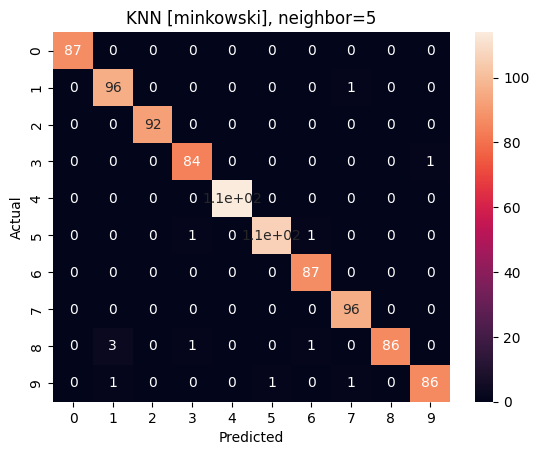

In [11]:
conf_mat = pd.crosstab(
    testLabels,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(
    conf_mat,
    annot=True
).set(
    title='KNN [minkowski], neighbor=5'
)

In [12]:
results = []

for i in [1, 2, 3, 4, 5]:

    model = KNeighborsClassifier(
        n_neighbors=i,
        metric='minkowski',
        p=2
    )

    model.fit(trainingMat, hwLabels)

    y_pred = model.predict(testMat)

    Accuracy_score = metrics.accuracy_score(
        testLabels,
        y_pred
    )

    results.append(Accuracy_score)

print(results)

[0.9862579281183932, 0.9778012684989429, 0.9873150105708245, 0.9830866807610994, 0.9799154334038055]


In [13]:
models = pd.DataFrame({
    'n_neighbors': ['1', '2', '3', '4', '5'],
    'Accuracy Score': [
        results[0],
        results[1],
        results[2],
        results[3],
        results[4]
    ]
})

models.sort_values(
    by='Accuracy Score'
)

print(
    models.to_string(index=False)
)

n_neighbors  Accuracy Score
          1        0.986258
          2        0.977801
          3        0.987315
          4        0.983087
          5        0.979915
